# Primera Práctica: Predicción de Subscripción a un Producto Bancario.

### Somos Lidia Valera López y Ana Díaz Jiménez del grupo 81
### Correos: 100522236@alumnos.uc3m.es y 100522155@alumnos.uc3m.es, respectivamente. 
### NIAS: 100522236 y 100522155, respectivamente
### Nuestra semilla es la de la alumna Lidia Valera López, por lo que nuestro bank es el 9 (3+6)

## 1. EDA Simplificado

### Cargar los datos

Lo primero que hacemos es cargar nuestros datos y además mostraremos las primeras filas del DataFrame

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Definimos nuestra variable NIA con uno de nuestros NIAS, en nuestro caso el de Lidia Valera López
NIA = 100522236
# Cargamos los datos
df = pd.read_pickle("bank_09.pkl") 

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Número de instancias y variables

In [2]:
n_instancias, n_variables = df.shape

print(f"Número de instancias: {n_instancias}")
print(f"Número de variables: {n_variables}")

Número de instancias: 11000
Número de variables: 17


### Tipo de variables

A continuación obersavermos si las variables son numéricas, categóricas u ordinales

In [3]:
# Definimos el target
target = "deposit"

# Vemos en el DataFrame que la variable "education" es ordinal, por lo que la incluimos en la lista de variables ordinales
ordinal_vars = ["education"]

# Detectamos variables numéricas
num_vars = df.select_dtypes(include=[np.number]).columns.tolist()

# Detectamos variables booleanas (contienen yes/no, Yes/No o True/False)
bool_vars = [col for col in df.columns if col != target and df[col].dropna().isin(['yes','no','Yes','No',True,False]).all()]

# Detectamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Quitamos las columnas ordinales de las categóricas
cat_vars = [var for var in cat_vars if var not in ordinal_vars]

# Excluimos booleanas de categóricas y quitamos tambien la variable target de las categóricas
cat_vars = [var for var in cat_vars if var not in bool_vars and var != target]

# Mostramos resultados
print(f"Variables numéricas: {num_vars}")
print(f"Variables categóricas: {cat_vars}")
print(f"Variables ordinales: {ordinal_vars}")
print(f"Variables booleanas: {bool_vars}")

# Además comprobamos que no nos dejemos ninguna (+1 de la variable target)
total_detectadas = len(num_vars) + len(bool_vars) + len(cat_vars) + len(ordinal_vars) + 1
print(f"\nTotal variables detectadas: {total_detectadas} (de {df.shape[1]})")


Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'contact', 'month', 'poutcome']
Variables ordinales: ['education']
Variables booleanas: ['default', 'housing', 'loan']

Total variables detectadas: 17 (de 17)


Vemos de que tipo son todas nuestras variables y si las sumamos comprobamos que efectivamente hay 17, como habiamos visto en el apartado anterior. Además, separamos nuestra variable deposit (el target) ya que no es un atributo (feature) y nos podría causar data leakage ya que es la variable que queremos predecir

### Cardinalidad de variables categóricas

Comprobamos las variables categóricas con alta cardinalidad, que son las que tienen mas de 10 valores únicos

In [4]:
for var in cat_vars:
    if df[var].nunique() > 10:
        print(f"La variable {var} tiene alta cardinalidad: {df[var].nunique()} valores únicos")

La variable job tiene alta cardinalidad: 12 valores únicos
La variable month tiene alta cardinalidad: 12 valores únicos


Vemos que tanto la vaiable job como la variable month tiene una alta cardinalidad

### Variables con valores faltantes

In [5]:
# Detectamos valores nulos reales (NaN) 
nulos = df.isnull().sum() 
nulos = nulos[nulos > 0]
if not nulos.empty:
    print("Variables con nulos (NaN):\n", nulos)
else:
    print("No hay nulos (NaN) en el dataset.")

# Tambien detectamos valores nulos pero ahora en formato texto (unknown, None, etc.)
busqueda_nulos = ['unknown', 'None', 'none', 'null']

for col in df.select_dtypes(include=['object']):
    # Extraemos los valores únicos de la columna 
    valores_unicos = df[col].unique()
    # Comprobamos si alguno de los valores de busqueda_nulos está presente en los valores únicos de la columna
    encontrados = [v for v in busqueda_nulos if v in valores_unicos]
    
    if encontrados:
        print(f"La variable '{col}' tiene valores de tipo nulo/desconocido: {encontrados}")

Variables con nulos (NaN):
 job         97
marital    282
dtype: int64
La variable 'job' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'education' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'contact' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'poutcome' tiene valores de tipo nulo/desconocido: ['unknown']


Estos valores nulos (NaN) son importantes porque al entrenar un modelo con KNN o un Árbol, el código se detendrá y nos dará un error, ya que Scikit-Learn no sabe que hacer con estos valores. Además, los valores "unknown" pueden engañar al modelo.

Es por esto que en a fase de preprocesamiento, usaremos una estrategia de imputación para las variables con pocos nulos como job o marital. Para variables como poutcome donde parece que hay muchos valores "unknown" analizaremos si merece la pena mantener esa variable o si este valor aporta realmente información por si mismo.

### Columnas constantes

In [6]:
print("Frecuencias de los valores únicos:")
for var in df.columns:
    value = df[var].value_counts().max() / len(df)
    print(f"{var}: {value:.2f}")
    if value > 0.85:
        print(f"{var} es una variable muy constante")
    if value == 1.0:
        print(f"{var} es una variable constante")
constantes = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", constantes)
# No se han encontrado variables constantes.

Frecuencias de los valores únicos:
age: 0.04
job: 0.23
marital: 0.56
education: 0.49
default: 0.98
default es una variable muy constante
balance: 0.07
housing: 0.53
loan: 0.87
loan es una variable muy constante
contact: 0.72
day: 0.05
month: 0.25
duration: 0.00
campaign: 0.43
pdays: 0.75
previous: 0.75
poutcome: 0.75
deposit: 0.53
Columnas constantes: []


No tenemos columnas constantes, porque no hay ninguna que tengan frecuencia máxima = 1.0 ( es decir, que todos los valores son iguales), pero las columnas de default y loan son muy constantes, ya que tienen un 85% de un valor, pero no son estrictamente constantes. Si hubiera alguna columna constante, deberia eliminarse ya que no aportan información al modelo, pero no es el caso

### Columnas tipo ID

In [7]:
posibles_id = [col for col in df.columns if df[col].nunique() == len(df)]
print("Columnas tipo ID:", posibles_id)

if posibles_id == []:
    print("No se han encontrado variables que podrían ser IDs (todos los valores son únicos).")

Columnas tipo ID: []
No se han encontrado variables que podrían ser IDs (todos los valores son únicos).


Como podemos ver, no hay ninguna columna que sea tipo ID

### Tipo de problema

Ahora vemos si es un problema de clasificación o regresión. Para ello nos fijaremos en la variable deposit que es la variable objetivo

In [8]:
target = "deposit"
print(df[target].dtype)
print(df[target].nunique(), "valores únicos")
df["deposit"].value_counts()

object
2 valores únicos


deposit
no     5780
yes    5220
Name: count, dtype: int64

Como vemos arriba, el target presenta dos valores únicos lo que supone un problema de clasificación binaria.

Además, como la variable target toma valores categóricos (yes/no) será necesario realizar una codificación (Encoding) para tranformarlo en valores numéricos (0 y 1) antes de entrenar los modelos, ya que los modelos no entienden estas palabras.

### ¿Está balanceado?

A continuación, vamos a ver si la variable deposit está balanceada

deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64


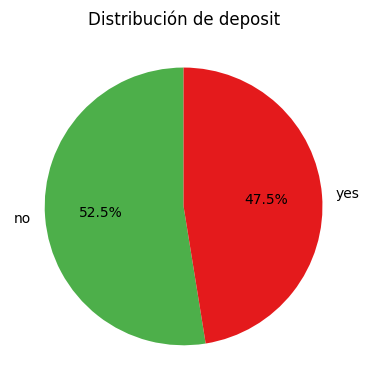

In [9]:
target = "deposit"
props = df[target].value_counts(normalize=True)

print(props)

# Comprobamos que no haya mas de un 70% de datos que pertenecen a una sola clase, ya que significaria que esta desbalanceado
if props.iloc[0] > 0.70:
    print(f"El target '{target}' está desbalanceado: {props[0]:.2f} de la clase mayoritaria.")

# Gráfico pie para visualizar la distribución del target
plt.figure(figsize=(4, 4))
props.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4daf4a", "#e41a1c"],
    legend=False,
    ylabel=""
)
plt.title("Distribución de deposit")
plt.tight_layout()
plt.show()

Como observamos en el gráfico, los datos estan balanceados, ya que hay un 52,2% de "no" y 47,5% de "yes". Por esto, no será necesiario aplicar técnicas de oversampling o undersampling para corregir desbalanceos.

### Analisis pdays

Estadísticas generales de pdays:
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Los 10 valores más frecuentes de deposit:
deposit
no     5780
yes    5220
Name: count, dtype: int64

Clientes no contactados previamente (-1): 8203 (74.57%)
Clientes contactados previamente: 2797 (25.43%)


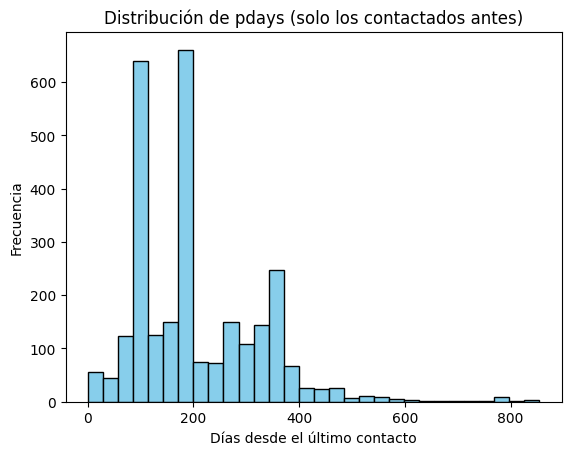

In [10]:
var_pdays = "pdays"

# Estadísticas generales
print(f"Estadísticas generales de {var_pdays}:")
print(df[var_pdays].describe())
print()
print(f"Los 10 valores más frecuentes de {target}:")
print(df[target].value_counts().head(10))

# Contamos cuántos clientes son no contactados, es decir valen -1 y cuántos son contactados, es decir valen diferente de -1 y 
# calculamos la proporción de no contactados respecto al total de clientes
n_no_contacted = (df[var_pdays] == -1).sum()
n_contacted = (df[var_pdays] != -1).sum()
prop_no_contactado = n_no_contacted / len(df)

print(f"\nClientes no contactados previamente (-1): {n_no_contacted} ({prop_no_contactado:.2%})")
print(f"Clientes contactados previamente: {n_contacted} ({1 - prop_no_contactado:.2%})")

# Histograma de pdays para los contactados (pdays != -1)
pdays_contacted = df.loc[df[var_pdays] != -1, var_pdays]
plt.hist(pdays_contacted, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de pdays (solo los contactados antes)")
plt.xlabel("Días desde el último contacto")
plt.ylabel("Frecuencia")
plt.show()


La variable pdays respresenta el número de días desde el último contacto con el cliente. El valor de -1 indica que el cliente no habia sido contactado previamete.
Gracias a los resultados, vemos que el 74,57% de los clientes nunca habían sido contactados antes, mientras que el 25,43% sí habian sido contactados.

Para analizar la distribución real de los días desde el último contacto a traves del histograma, se excluyeron los valores -1, ya que son un caso especial y si no lo hicieramos, el histograma quedaría dominado por este valor.

Para los modelos basados en distancias como KNN o SVM, este -1 puede ser problemático al ser tratado como un valor cercano a 0, por lo que en la fase de preprocesamiento evaluaremos si tratar esta variable como categórica o si crear una variable biaria adicional (como "contactado antes": si/no) para que el modelo no se confunda con el valor numérico.

## 2. Decidir como se va a realizar la evaluación

Como hemos analizado anteriormente, la variable objetivo está bastante balanceada (52% vs 48%). Es por esto que hemos elegido como métrica principal el Accuracy. Además, es una métrica con una interpretación sencilla que nos dirá el porcentaje de predicciones totales correctas y en escenarios equilibrados como este, Accuracy es una medida fiable de rendimiento general.

Por otro lado, aunque los datos estén balanceados, desde una perspectiva de negocio como es el banco, no todos los errores tienen el mismo coste. Al banco le interesa no perder clientes potenciales (falsos negativos). Por lo que utilizaremos además Recall para la clase "yes", permitiéndonos asegurar que el modelo sea capaz de identificar a la mayor cantidad posible de clientes dispuestos a suscribir el depósito.

### División holdout (train/test)

In [11]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y variable objetivo
x = df.drop(columns=["deposit"]) # Variables predictoras (features)
y = df["deposit"] # Variable objetivo (target)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3,
                                                    stratify=y,
                                                      random_state=NIA)

print("Tamaño del conjunto de entrenamiento:", x_train.shape[0])
print("Tamaño del conjunto de prueba:", x_test.shape[0])


Tamaño del conjunto de entrenamiento: 7333
Tamaño del conjunto de prueba: 3667


### Inner evaluation (crossvalidation)

Para la evaluación interna se empleará validación cruzada estratificada en 5 folds (Stratified 5-Fold CV), ya que garantiza que en cada una de las 5 particiones, la proporción de clientes que dicen 'yes' y 'no' sea la misma que en el conjunto de entrenamiento, con lo que obtenemos una estimación mucho más fiable del rendimiento que si usáramos una única partición y porque nos ayudará a buscar los mejores hiperparámetros sin tocar el conjunto de test hasta el final.

In [12]:
from sklearn.model_selection import StratifiedKFold

# Definimos el esquema de validación cruzada para la evaluación interna (Inner)
cv = StratifiedKFold(
    n_splits=5, # 5 folds
    shuffle=True,
    random_state=NIA
)
#Diccionario para almacenar los resultados de las validaciones cruzadas
inner_scores = {}

El diccionario inner_scores lo utilizaremos para guardar los resultados que saquemos en la validacion cruzada a medida que vayamos probando modelos distintos, para que al final de la práctica solo tengamos que imprimir el diccionario para ver que moelo es mejor.

## 3. Métodos básicos: KNN y TREES

### Elegir método de escalado más apropiado usando KNN

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import numpy as np

# Definimos los escaladores a probar
scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}
# Definimos el orden lógico para la variable ordinal (incluyendo unknown al final), que es educación
educ_levels = [['primary', 'secondary', 'tertiary', 'unknown']]
# Definimos el preprocesador para cada tipo de variable. Tratamos las binarias con OneHotEncoder o OrdinalEncoder para pasarlas a número
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_vars), 
        ('bool', OneHotEncoder(drop='if_binary', sparse_output=False), bool_vars),
        ('ord', OrdinalEncoder(categories=educ_levels), ['education'])
    ]
)
# Creamos una variable para almacenar las sumas de las accuracies de cada iteración de validación cruzada para cada escalador
scores = {'Standard': 0, 'MinMax': 0, 'Robust': 0}

print("Iteraciones de validación cruzada:")

for train_index, val_index in cv.split(x_train, y_train):
    # Separamos los folds usando x_train para evitar Data Leakage
    X_tr, X_va = x_train.iloc[train_index], x_train.iloc[val_index]
    y_tr, y_va = y_train.iloc[train_index], y_train.iloc[val_index]

    for name, scaler in scalers.items():
        pipe = Pipeline([
            ('prepro', preprocessor),
            ('scaler', scaler),
            ('knn', KNeighborsClassifier())
        ])
        # Entrenamos y evaluamos el fold
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_va)
        scores[name] += metrics.accuracy_score(y_va, y_pred)

# Calculamos la media dividiendo por el número de folds (cv.n_splits)
n_folds = cv.get_n_splits()
print(f"\nResultados (Media de {n_folds} folds):")

for name in scores:
    scores[name] /= n_folds
    print(f"Accuracy para {name}: {scores[name]:.4f}")

# Identificamos el mejor método de escalado y mostramos su nombre
mejor_escalador_nombre = max(scores, key=scores.get)
print(f"\nEl mejor método de escalado es: {mejor_escalador_nombre}")


Iteraciones de validación cruzada:

Resultados (Media de 5 folds):
Accuracy para Standard: 0.7618
Accuracy para MinMax: 0.7173
Accuracy para Robust: 0.7960

El mejor método de escalado es: Robust


El método de escalado que tiene el mayor accuracy es Robust, con un valor de 0,7960. 

### KNN y Árboles

#### Evaluación de hiperparámetros por omisión

In [27]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

modelos = {
    'KNN (Mejor Scaler)': Pipeline([
        ('prepro', preprocessor),
        ('scaler', RobustScaler()),
        ('knn', KNeighborsClassifier()) # Parámetros por defecto (k=5)
    ]),
    'Árbol de Decisión': Pipeline([
        ('prepro', preprocessor),
        ('dt', DecisionTreeClassifier(random_state=NIA)) # Parámetros por defecto
    ])
}

print("Evaluación de modelos con hiperparámetros por omisión:\n")

# Creamos un scorer específico para 'yes' porque queremos medir tambien el recall y este solo acepta una clase positiva, que en nuestro caso es 'yes' (clientes que sí hicieron el depósito)
scorer_recall_yes = make_scorer(recall_score, pos_label='yes')

for nombre, pipe in modelos.items():
    # Medimos el tiempo de un solo entrenamiento, ya que si midieramos el de cross validation, estariamos midiendo el tiempo de 5 entrenamientos
    inicio_t = time.time()
    pipe.fit(x_train, y_train) 
    fin_t = time.time()
    tiempo_real = fin_t - inicio_t
    
    # Ahora medimos la calidad del modelo con cross validation
    # Usamos scoring='accuracy' y también podríamos sacar el 'recall'
    scores_acc = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='accuracy')
    scores_rec = cross_val_score(pipe, x_train, y_train, cv=cv, scoring=scorer_recall_yes)
    
    print(f"-{nombre}:")
    print(f"Tiempo de 1 entrenamiento: {tiempo_real:.4f}s")
    print(f"Accuracy (Media CV): {scores_acc.mean():.4f}")
    print(f"Recall 'yes' (Media CV): {scores_rec.mean():.4f}")
    print("----------------------------------")

Evaluación de modelos con hiperparámetros por omisión:

-KNN (Mejor Scaler):
Tiempo de 1 entrenamiento: 0.0475s
Accuracy (Media CV): 0.7960
Recall 'yes' (Media CV): 0.7506
----------------------------------
-Árbol de Decisión:
Tiempo de 1 entrenamiento: 0.0691s
Accuracy (Media CV): 0.7866
Recall 'yes' (Media CV): 0.7655
----------------------------------


En esta evaluación inicial con parámetros por defecto, observamos que el modelo KNN con RobustScaler ofrece un accuracy ligeramente superior (79.6%). Sin embargo, el Árbol de Decisión destaca por su capacidad de identificar clientes potenciales (Recall de 76.5%), lo cual seria mejor a la hora de encontrar a los clientes que si que quieren el depósito.

Además, ambos modelos tienen tiempos de ejecución muy reducidos (inferiores a 0.1s), por lo que no tendremos costes computacionales elevados.

#### Interpretacion de como concebir decisiones a través de árboles poco profundos